In [7]:
pip install seaborn


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


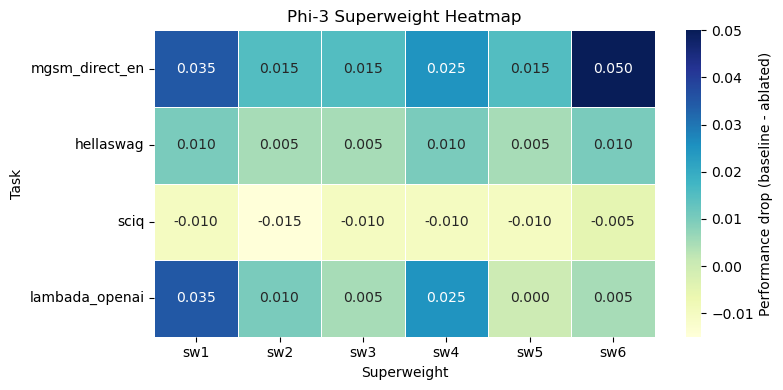

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../../results/task_heatmaps/phi3_heatmap.csv")

category_order = ["math", "reasoning", "knowledge", "causal"]

task_order = (
    df[["task", "category"]]
    .drop_duplicates()
    .assign(category=lambda x: pd.Categorical(x["category"], categories=category_order, ordered=True))
    .sort_values(["category", "task"])["task"]
    .tolist()
)

pivot = df.pivot(index="task", columns="superweight_id", values="delta_abs").loc[task_order]

plt.figure(figsize=(8, 4))
sns.heatmap(
    pivot,
    annot=True,
    fmt=".3f",
    cmap="YlGnBu",
    linewidths=0.5,
    cbar_kws={"label": "Performance drop (baseline - ablated)"}
)
plt.title("Phi-3 Superweight Heatmap")
plt.xlabel("Superweight")
plt.ylabel("Task")
plt.tight_layout()
plt.show()

<Axes: xlabel='superweight_id', ylabel='task'>

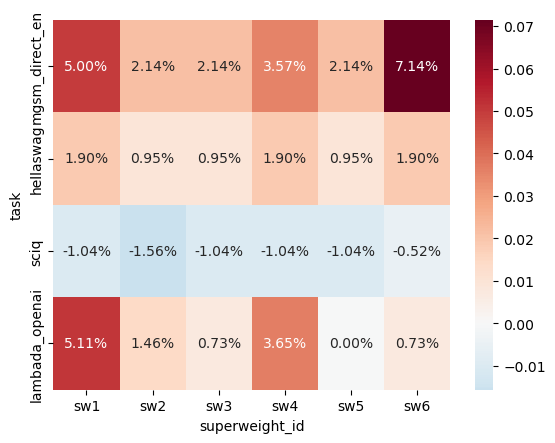

In [9]:
pivot_rel = df.pivot(index="task", columns="superweight_id", values="delta_rel").loc[task_order]

sns.heatmap(
    pivot_rel,
    annot=True,
    fmt=".2%",
    cmap="RdBu_r",
    center=0
)

<Axes: xlabel='superweight_id', ylabel='category'>

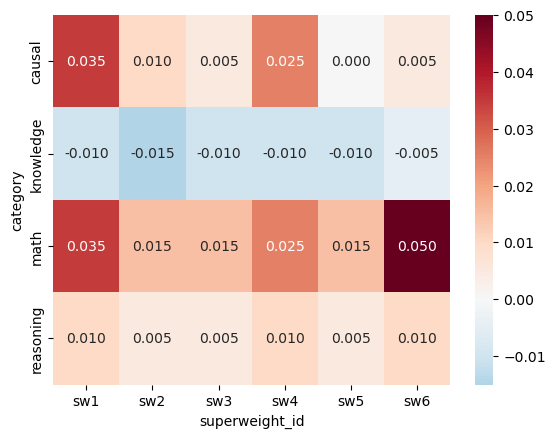

In [10]:
grouped = df.groupby(["category", "superweight_id"])["delta_abs"].mean().reset_index()

pivot_cat = grouped.pivot(index="category", columns="superweight_id", values="delta_abs")

sns.heatmap(
    pivot_cat,
    annot=True,
    fmt=".3f",
    cmap="RdBu_r",
    center=0
)